In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression,SGDRegressor
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder,OneHotEncoder
from sklearn.feature_extraction.text import  CountVectorizer
from sklearn.ensemble import (RandomForestClassifier,RandomForestRegressor,HistGradientBoostingClassifier)
from sklearn.naive_bayes import (BernoulliNB,MultinomialNB,GaussianNB)
from sklearn.model_selection import train_test_split,RandomizedSearchCV
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
Ecom_data=pd.read_csv('Cleaned E-commerce Dataset.csv')


In [3]:
Ecom_data.rename(columns={' MV ' : 'Total_before_disc'},inplace=True)
Ecom_data2=Ecom_data[Ecom_data['status'].isin(['Cancelled','Completed'])].copy()
Ecom_updated=Ecom_data2.drop(['Total_before_disc'],axis=1).copy()
payement_index=Ecom_updated[Ecom_updated['payment_method']=='Other'].index
Ecom_updated.drop(payement_index,axis=0,inplace=True)

## Categorical to  Dummy Variables & Train Test Split
Cancelled==0 
Complete=1

In [4]:
y=Ecom_updated['status']
le=LabelEncoder()
y=le.fit_transform(y)
Final_x=pd.get_dummies(Ecom_updated.drop('status',axis=1),dtype='int64',drop_first=True)
Train_x,Test_x,Train_y,Test_y=train_test_split(Final_x,y,stratify=y,random_state=42,test_size=0.2)

## Hyperparameter Tunning (Randomized Search CV)

In [5]:
param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 4, 5, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5, 7],
    'gamma': [0, 0.1, 0.2, 0.3],
    'reg_alpha': [0, 0.01, 0.1, 1],       # L1 regularization
    'reg_lambda': [1, 1.5, 2, 3]          # L2 regularization
}

xgb = XGBClassifier(
    tree_method='hist',      # fast, built for large datasets
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_grid,
    n_iter=30,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    random_state=42,
    verbose=2                # shows progress, helpful for big datasets
)

random_search.fit(Train_x,Train_y)  # tune on the 50K sample first

print(random_search.best_params_)
print(random_search.best_score_)

Fitting 3 folds for each of 30 candidates, totalling 90 fits
{'subsample': 0.8, 'reg_lambda': 1.5, 'reg_alpha': 1, 'n_estimators': 500, 'min_child_weight': 5, 'max_depth': 8, 'learning_rate': 0.1, 'gamma': 0.1, 'colsample_bytree': 0.7}
0.7397199676980982


## XGBClassifier with best parameters

In [6]:
best_parameter={'subsample': 0.8, 'reg_lambda': 1.5, 'reg_alpha': 1, 'n_estimators': 500, 'min_child_weight': 5, 'max_depth': 8, 'learning_rate': 0.1, 'gamma': 0.1, 'colsample_bytree': 0.7}
Xgb=XGBClassifier(best_parameter,ree_method='hist',eval_metric='logloss',random_state=42,n_jobs=-1)
Xgb.fit(Train_x,Train_y)
y_pred=Xgb.predict(Test_x)

C:\Users\Hamza Sajid\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:200: UserWarning: [21:49:12] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:793: 
Parameters: { "ree_method" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


##  overall Accuracy & Precision Checking 

<Axes: >

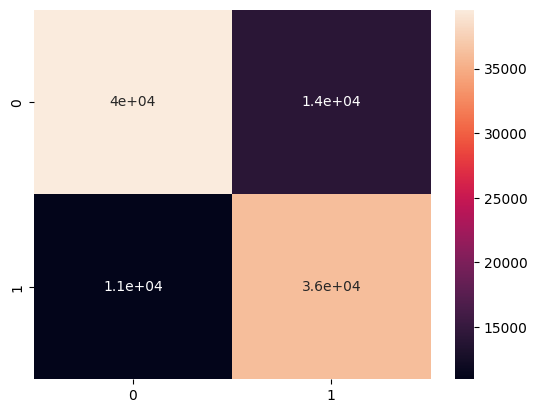

In [7]:
cm=confusion_matrix(Test_y,y_pred)
import seaborn as sn
sn.heatmap(cm,annot=True)

In [13]:
print(classification_report(Test_y,y_pred))

              precision    recall  f1-score   support

           0       0.78      0.74      0.76     53756
           1       0.72      0.77      0.74     47060

    accuracy                           0.75    100816
   macro avg       0.75      0.75      0.75    100816
weighted avg       0.75      0.75      0.75    100816



Model Loading

In [16]:
import joblib
joblib.dump(Xgb,'Status Prediction Model (E-commerce).pkl')


['Status Prediction Model (E-commerce).pkl']